In [2]:
import pandas as pd
from datetime import datetime
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.api import VAR
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.stats import pearsonr
from statsmodels.tsa.stattools import adfuller
import math
from sklearn.preprocessing import StandardScaler

## Data

In [3]:
# import data
df= pd.read_csv("import_2022.csv")

In [4]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2605 entries, 0 to 2604
Data columns (total 61 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   qa3_01         2605 non-null   int64
 1   qa3_02         2605 non-null   int64
 2   qa3_03         2605 non-null   int64
 3   qa3_04         2605 non-null   int64
 4   qa3_05         2605 non-null   int64
 5   qa3_06         2605 non-null   int64
 6   qa3_07         2605 non-null   int64
 7   qa3_08         2605 non-null   int64
 8   qa3_09         2605 non-null   int64
 9   qa4_01         2605 non-null   int64
 10  qa4_02         2605 non-null   int64
 11  qa4_03         2605 non-null   int64
 12  qa4_04         2605 non-null   int64
 13  qa4_05         2605 non-null   int64
 14  qa4_06         2605 non-null   int64
 15  qa4_07         2605 non-null   int64
 16  qa4_08         2605 non-null   int64
 17  qa4_09         2605 non-null   int64
 18  qa13_01        2605 non-null   int64
 19  qa13_0

None

## Risk Aversion

### Gain - 50%の確率で10万円が当たる「スピードくじ」の値段

Transformed price = 1 − λ/50,000 <br>
Note that the greater a respondent’s value of transformed price, the more risk averse the respondent is. In our setting, the values of transformed price only take values between zero and one, where the value of zero corresponds to the case of perfectly risk-neutral preference.

In [6]:
# Function to calculate calculate_price based on conditions
def calculate_price(row):
    conditions = {
        (2, 2, 2, 2, 2, 2, 2, 2): 0.9998,
        (1, 2, 2, 2, 2, 2, 2, 2): 0.9799,
        (1, 1, 2, 2, 2, 2, 2, 2): 0.94,
        (1, 1, 1, 2, 2, 2, 2, 2): 0.88,
        (1, 1, 1, 1, 2, 2, 2, 2): 0.77,
        (1, 1, 1, 1, 1, 2, 2, 2): 0.6,
        (1, 1, 1, 1, 1, 1, 2, 2): 0.4,
        (1, 1, 1, 1, 1, 1, 1, 2): 0.15,
        (1, 1, 1, 1, 1, 1, 1, 1): 0
        
    }
    # Ensure the order matches exactly as in your conditions dictionary
    key = (row['qa15_01'], row['qa15_02'], row['qa15_03'], row['qa15_04'],
           row['qa15_05'], row['qa15_06'], row['qa15_07'], row['qa15_08'])
    return conditions.get(key, 'unknown')  # return 'unknown' if no match is found

# Apply function to calculate rho
df['Risk_Gain'] = df.apply(calculate_price, axis=1)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2605 entries, 0 to 2604
Data columns (total 62 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   qa3_01         2605 non-null   int64 
 1   qa3_02         2605 non-null   int64 
 2   qa3_03         2605 non-null   int64 
 3   qa3_04         2605 non-null   int64 
 4   qa3_05         2605 non-null   int64 
 5   qa3_06         2605 non-null   int64 
 6   qa3_07         2605 non-null   int64 
 7   qa3_08         2605 non-null   int64 
 8   qa3_09         2605 non-null   int64 
 9   qa4_01         2605 non-null   int64 
 10  qa4_02         2605 non-null   int64 
 11  qa4_03         2605 non-null   int64 
 12  qa4_04         2605 non-null   int64 
 13  qa4_05         2605 non-null   int64 
 14  qa4_06         2605 non-null   int64 
 15  qa4_07         2605 non-null   int64 
 16  qa4_08         2605 non-null   int64 
 17  qa4_09         2605 non-null   int64 
 18  qa13_01        2605 non-null

## Male 

In [8]:
df['Male'] = df['Male12'].apply(lambda x: 1 if x == 1 else 0)

## Marital Status

In [9]:
df['Spouse'] = df['qb2'].apply(lambda x: 1 if x == 1 or x == 2 else 0)

## Age

In [10]:
# Function to calculate age
def calculate_age(year, month):
    today = datetime.today()
    birth_date = datetime(year, month, 1)
    age = today.year - birth_date.year - ((today.month, today.day) < (birth_date.month, birth_date.day))
    return age

# Create a new column for age
df['Age'] = df.apply(lambda row: calculate_age(row['qb3y'], row['qb3m']), axis=1)

## Housing

In [11]:
df['Residence'] = df['qb33'].apply(lambda x: 1 if x == 1 or x == 2 else 0)

## Income, Property, Financial Assets, 

In [12]:
# Income:
conditions = [
    (df['Income_pre'] == 1),
    (df['Income_pre'] == 2),
    (df['Income_pre'] == 3),
    (df['Income_pre'] == 4),
    (df['Income_pre'] == 5),
    (df['Income_pre'] == 6),
    (df['Income_pre'] == 7),
    (df['Income_pre'] == 8),
    (df['Income_pre'] == 9),
    (df['Income_pre'] == 10),
    (df['Income_pre'] == 11),
    (df['Income_pre'] == 12)
    
]

choices = [100, 150, 300, 500, 700, 900, 1100, 1300, 1500, 1700, 1900, 2000]

df['Income'] = np.select(conditions, choices, default=np.nan)

# Property:
conditions = [
    (df['Property_pre'] == 1),
    (df['Property_pre'] == 2),
    (df['Property_pre'] == 3),
    (df['Property_pre'] == 4),
    (df['Property_pre'] == 5),
    (df['Property_pre'] == 6),
    (df['Property_pre'] == 7),
    (df['Property_pre'] == 8),
    (df['Property_pre'] == 9),
    (df['Property_pre'] == 10)
]

choices = [0, 500, 750, 1250, 1750, 2500, 3500, 4500, 7500, 10000]

df['Property'] = np.select(conditions, choices, default=np.nan)

# Asset_Amt:
conditions = [
    (df['Fin_Asset_pre'] == 1),
    (df['Fin_Asset_pre'] == 2),
    (df['Fin_Asset_pre'] == 3),
    (df['Fin_Asset_pre'] == 4),
    (df['Fin_Asset_pre'] == 5),
    (df['Fin_Asset_pre'] == 6),
    (df['Fin_Asset_pre'] == 7),
    (df['Fin_Asset_pre'] == 8),
    (df['Fin_Asset_pre'] == 9),
    (df['Fin_Asset_pre'] == 10)
]

choices = [250, 375, 625, 875, 1250, 1750, 2500, 4000, 7500, 10000]

df['Fin_Asset'] = np.select(conditions, choices, default=np.nan)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2605 entries, 0 to 2604
Data columns (total 69 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   qa3_01         2605 non-null   int64  
 1   qa3_02         2605 non-null   int64  
 2   qa3_03         2605 non-null   int64  
 3   qa3_04         2605 non-null   int64  
 4   qa3_05         2605 non-null   int64  
 5   qa3_06         2605 non-null   int64  
 6   qa3_07         2605 non-null   int64  
 7   qa3_08         2605 non-null   int64  
 8   qa3_09         2605 non-null   int64  
 9   qa4_01         2605 non-null   int64  
 10  qa4_02         2605 non-null   int64  
 11  qa4_03         2605 non-null   int64  
 12  qa4_04         2605 non-null   int64  
 13  qa4_05         2605 non-null   int64  
 14  qa4_06         2605 non-null   int64  
 15  qa4_07         2605 non-null   int64  
 16  qa4_08         2605 non-null   int64  
 17  qa4_09         2605 non-null   int64  
 18  qa13_01 

## Asset Type

In [14]:
# List of columns to check
columns_to_check = [f'qb36{str(i).zfill(2)}' for i in range(1, 15)]

# Filter out rows with any value of 9 in the specified columns
df_cleaned = df[~df[columns_to_check].isin([9]).any(axis=1)].copy()


In [15]:
# １ 銀行預金（信用金庫、信用組合、農協などを含む）
# ２ 郵便貯金 ３ 生命保険 ４ 株式 
# ５ 投資信託 ６ 外貨預金 ７ 先物・オプション
# ８ 日本の国債 ９ 外国債 10 個人年金（生命保険会社や郵便年金）
# 11 企業年金 12 現金貯金（いわゆるタンス預金）
# 13 その他（ ）

# List of columns to sum for Asset_Type, excluding qb3608
columns_to_sum = [f'qb36{str(i).zfill(2)}' for i in range(4, 9)]

# Create the new column 'Asset_Type' by summing the specified columns
df_cleaned['Asset_Type'] = df_cleaned[columns_to_sum].sum(axis=1)

In [16]:
df_cleaned['Stock'] = df['qb3604'].apply(lambda x: 1 if x == 1 else 0)
df_cleaned['MF'] = df['qb3605'].apply(lambda x: 1 if x == 1 else 0)

In [17]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2493 entries, 0 to 2604
Data columns (total 72 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   qa3_01         2493 non-null   int64  
 1   qa3_02         2493 non-null   int64  
 2   qa3_03         2493 non-null   int64  
 3   qa3_04         2493 non-null   int64  
 4   qa3_05         2493 non-null   int64  
 5   qa3_06         2493 non-null   int64  
 6   qa3_07         2493 non-null   int64  
 7   qa3_08         2493 non-null   int64  
 8   qa3_09         2493 non-null   int64  
 9   qa4_01         2493 non-null   int64  
 10  qa4_02         2493 non-null   int64  
 11  qa4_03         2493 non-null   int64  
 12  qa4_04         2493 non-null   int64  
 13  qa4_05         2493 non-null   int64  
 14  qa4_06         2493 non-null   int64  
 15  qa4_07         2493 non-null   int64  
 16  qa4_08         2493 non-null   int64  
 17  qa4_09         2493 non-null   int64  
 18  qa13_01 

In [18]:
df_filtered = df_cleaned[(df_cleaned['Risk_Gain'] != 'unknown')]
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2381 entries, 0 to 2604
Data columns (total 72 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   qa3_01         2381 non-null   int64  
 1   qa3_02         2381 non-null   int64  
 2   qa3_03         2381 non-null   int64  
 3   qa3_04         2381 non-null   int64  
 4   qa3_05         2381 non-null   int64  
 5   qa3_06         2381 non-null   int64  
 6   qa3_07         2381 non-null   int64  
 7   qa3_08         2381 non-null   int64  
 8   qa3_09         2381 non-null   int64  
 9   qa4_01         2381 non-null   int64  
 10  qa4_02         2381 non-null   int64  
 11  qa4_03         2381 non-null   int64  
 12  qa4_04         2381 non-null   int64  
 13  qa4_05         2381 non-null   int64  
 14  qa4_06         2381 non-null   int64  
 15  qa4_07         2381 non-null   int64  
 16  qa4_08         2381 non-null   int64  
 17  qa4_09         2381 non-null   int64  
 18  qa13_01 

In [19]:
# Drop columns starting with 'qa'
columns_to_drop = [col for col in df_filtered.columns if col.startswith('q')]
df_filtered = df_filtered.drop(columns=columns_to_drop)
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2381 entries, 0 to 2604
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Rain           2381 non-null   int64  
 1   Male12         2381 non-null   int64  
 2   Income_pre     2381 non-null   int64  
 3   Property_pre   2381 non-null   int64  
 4   Fin_Asset_pre  2381 non-null   int64  
 5   Risky_Asset    2381 non-null   int64  
 6   Risk_Gain      2381 non-null   object 
 7   Male           2381 non-null   int64  
 8   Spouse         2381 non-null   int64  
 9   Age            2381 non-null   int64  
 10  Residence      2381 non-null   int64  
 11  Income         2247 non-null   float64
 12  Property       2262 non-null   float64
 13  Fin_Asset      2184 non-null   float64
 14  Asset_Type     2381 non-null   int64  
 15  Stock          2381 non-null   int64  
 16  MF             2381 non-null   int64  
dtypes: float64(3), int64(13), object(1)
memory usage: 33

In [20]:
df_filtered = df_filtered.drop(columns=['Male12','Income_pre','Property_pre','Fin_Asset_pre'])

In [21]:
# Further filter the DataFrame based on the specified conditions
conditions = (
    (df_filtered['Rain'] != 999) 
#     &
#     (df_filtered['Income'] != 99) &
#     (df_filtered['Property'] != 99) &
#     (df_filtered['Fin_Asset'] != 99) 
#    &(~df_filtered['Risky_Asset'].isin([888, 999]))
)

df_filtered = df_filtered[conditions]

#df_filtered = df_filtered[~((df_filtered['Risky_Asset'] > 0) & (df_filtered['Asset_Type'] == 0))]

df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2328 entries, 0 to 2604
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Rain         2328 non-null   int64  
 1   Risky_Asset  2328 non-null   int64  
 2   Risk_Gain    2328 non-null   object 
 3   Male         2328 non-null   int64  
 4   Spouse       2328 non-null   int64  
 5   Age          2328 non-null   int64  
 6   Residence    2328 non-null   int64  
 7   Income       2197 non-null   float64
 8   Property     2212 non-null   float64
 9   Fin_Asset    2138 non-null   float64
 10  Asset_Type   2328 non-null   int64  
 11  Stock        2328 non-null   int64  
 12  MF           2328 non-null   int64  
dtypes: float64(3), int64(9), object(1)
memory usage: 254.6+ KB


In [22]:
df_filtered['Risk_Gain'] = pd.to_numeric(df_filtered['Risk_Gain'])

In [23]:
df_filtered.dropna(inplace = True)

In [24]:
df_filtered.info()
# df_filtered.to_csv(r"D:\_滋賀大学\03_Demographics\data_sf.csv", encoding="shift_jis")

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2056 entries, 0 to 2604
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Rain         2056 non-null   int64  
 1   Risky_Asset  2056 non-null   int64  
 2   Risk_Gain    2056 non-null   float64
 3   Male         2056 non-null   int64  
 4   Spouse       2056 non-null   int64  
 5   Age          2056 non-null   int64  
 6   Residence    2056 non-null   int64  
 7   Income       2056 non-null   float64
 8   Property     2056 non-null   float64
 9   Fin_Asset    2056 non-null   float64
 10  Asset_Type   2056 non-null   int64  
 11  Stock        2056 non-null   int64  
 12  MF           2056 non-null   int64  
dtypes: float64(4), int64(9)
memory usage: 224.9 KB


標準化

In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [26]:
# Define continuous and categorical columns
continuous_cols = ['Rain','Income','Property','Fin_Asset','Risky_Asset','Risk_Gain','Age','Asset_Type']
categorical_cols = ['Male','Spouse','Residence','Stock','MF']

# Standardize continuous columns
scaler = StandardScaler(with_mean=False)
df_filtered[continuous_cols] = scaler.fit_transform(df_filtered[continuous_cols])

# Print the standardized DataFrame
print(df_filtered)

          Rain  Risky_Asset  Risk_Gain  Male  Spouse       Age  Residence  \
0     2.521911     0.000000   4.751099     1       1  6.382448          1   
1     2.017529     0.130330   1.900820     1       1  6.212249          1   
2     2.017529     0.000000   2.851230     1       1  5.020859          1   
3     3.026293     0.000000   4.181803     0       1  6.042051          1   
7     2.521911     3.254984   4.751099     0       0  7.488739          1   
...        ...          ...        ...   ...     ...       ...        ...   
2600  4.035058     0.016291   4.181803     0       1  5.786753          1   
2601  4.035058     0.000000   4.181803     0       0  3.233774          0   
2602  1.513147     2.893319   4.181803     1       1  6.042051          1   
2603  1.513147     0.097747   2.851230     1       0  3.063575          1   
2604  2.521911     0.065165   3.659078     1       1  4.425164          1   

        Income  Property  Fin_Asset  Asset_Type  Stock  MF  
0     0.745070

In [27]:
df_filtered=df_filtered.drop(columns=['Asset_Type', 'Risky_Asset'])

In [28]:
display(df_filtered.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2056 entries, 0 to 2604
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Rain       2056 non-null   float64
 1   Risk_Gain  2056 non-null   float64
 2   Male       2056 non-null   int64  
 3   Spouse     2056 non-null   int64  
 4   Age        2056 non-null   float64
 5   Residence  2056 non-null   int64  
 6   Income     2056 non-null   float64
 7   Property   2056 non-null   float64
 8   Fin_Asset  2056 non-null   float64
 9   Stock      2056 non-null   int64  
 10  MF         2056 non-null   int64  
dtypes: float64(6), int64(5)
memory usage: 192.8 KB


None

# FCI

https://causal-learn.readthedocs.io/en/latest/search_methods_index/Constraint-based%20causal%20discovery%20methods/FCI.html#algorithm-introduction

In [29]:
#「PC/FCIにおいて混合データを扱うための機能の実装」に対応した causal-learn をインストールするためには、次のコマンドを実行します。
# !pip install git+https://github.com/cdt15/causal-learn.git

In [30]:
from causallearn.search.ConstraintBased.FCI import fci
from causallearn.utils.cit import kci
from causallearn.utils.PCUtils.BackgroundKnowledge import BackgroundKnowledge
# visualization
from causallearn.utils.GraphUtils import GraphUtils
import pydot
import io
import matplotlib.image as mpimg

In [31]:
# Randomly select 1200 samples
# df_sampled = df_filtered.sample(n=1200, random_state=42)

In [32]:
data_pre = df_filtered.to_numpy()

In [69]:
#G, edges = fci(data_pre, 'kci', 0.05)

In [71]:
# cg_without_background_knowledge = fci(
#     data_pre, 
#     is_discrete=[False, False, True, True, False, True, False, False, False, True, True],
#     independence_test_method="kci"
# )

  0%|          | 0/11 [00:00<?, ?it/s]

X7 --> X2
X7 --> X4
X9 --> X5
X8 --> X7
X9 --> X8
X9 --> X10


In [72]:
nodes = cg_without_background_knowledge[0].get_nodes()

for node in cg_without_background_knowledge[0].nodes: 
    print(node.get_name())

forbidden_edges = [
                   (0,2),(1,2),(3,2),(4,2),(5,2),(6,2),(7,2),(8,2),(9,2),(10,2),
                   (0,4),(1,4),(2,4),(3,4),(5,4),(6,4),(7,4),(8,4),(9,4),(10,4)
    
                  ]

X1
X2
X3
X4
X5
X6
X7
X8
X9
X10
X11


In [73]:
bk = BackgroundKnowledge()
for (node_1_idx, node_2_idx) in forbidden_edges:
    bk.add_forbidden_by_node(nodes[node_1_idx], nodes[node_2_idx])

G, edges = fci(
    data_pre,
#     'kci')
    is_discrete=[False, False, True, True, False, True, False, False, False, True, True],
    independence_test_method="kci",
    background_knowledge=bk)

  0%|          | 0/11 [00:00<?, ?it/s]

Starting BK Orientation.
Orienting edge (Knowledge): X5 --> X1
Orienting edge (Knowledge): X3 --> X2
Orienting edge (Knowledge): X5 --> X2
Orienting edge (Knowledge): X3 --> X4
Orienting edge (Knowledge): X3 --> X10
Orienting edge (Knowledge): X5 --> X4
Orienting edge (Knowledge): X5 --> X7
Orienting edge (Knowledge): X5 --> X9
Finishing BK Orientation.
Starting BK Orientation.
Orienting edge (Knowledge): X5 --> X1
Orienting edge (Knowledge): X3 --> X2
Orienting edge (Knowledge): X5 --> X2
Orienting edge (Knowledge): X3 --> X4
Orienting edge (Knowledge): X3 --> X10
Orienting edge (Knowledge): X5 --> X4
Orienting edge (Knowledge): X5 --> X7
Orienting edge (Knowledge): X5 --> X9
Finishing BK Orientation.
X7 --> X2
X7 --> X4
X8 --> X7
X9 --> X8
X9 --> X10


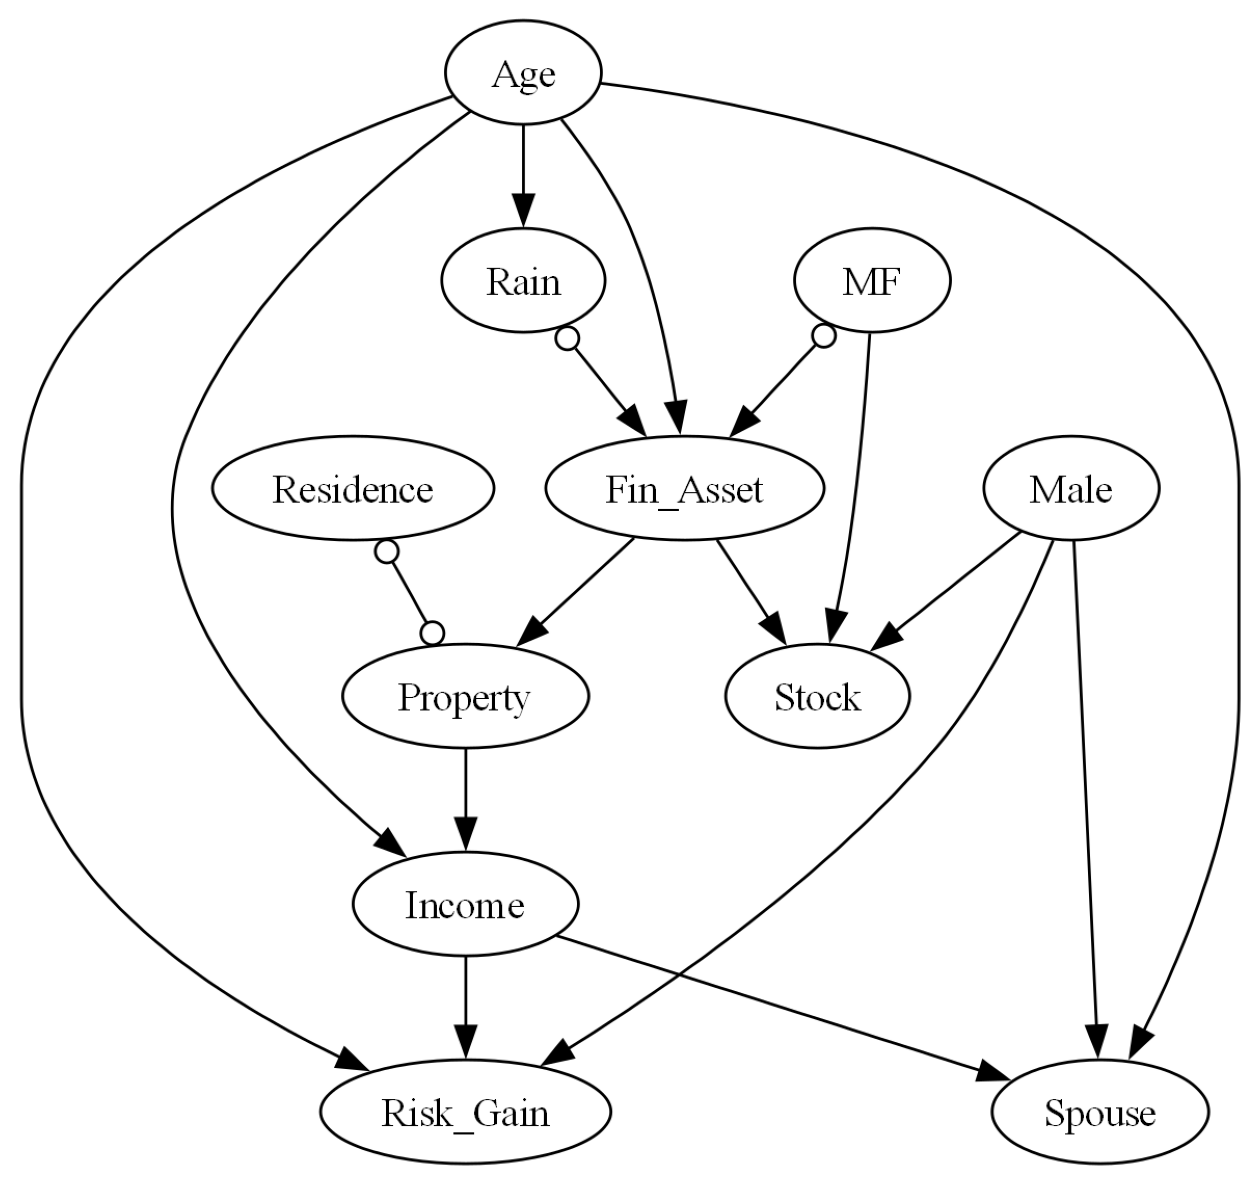

In [77]:
pyd = GraphUtils.to_pydot(G, labels=[
    'Rain',
    'Risk_Gain',
    'Male',
    'Spouse',
    'Age',
    'Residence',
    'Income',
    'Property',
    'Fin_Asset',

    'Stock',
    'MF'
    ])

tmp_png = pyd.create_png(f="png")
fp = io.BytesIO(tmp_png)
img = mpimg.imread(fp, format='png')
plt.figure(figsize=(16,16))
plt.axis('off')
plt.imshow(img)
plt.show()


# Bootstrap

In [33]:
import json
import pickle
import logging
from pathlib import Path
from datetime import datetime

from sklearn.utils import resample

N_ITER = 100
BASE_SEED = 42
IS_DISCRETE = [False, False, True, True, False, True, False, False, False, True, True]
TEST_METHOD = "kci"  

RUN_DIR = Path("./bootstrap_run_seed")
OUTPUT_DIR = RUN_DIR / "outputs_edges"
LOG_FILE = RUN_DIR / "bootstrap_run.log"
SEEDS_FILE = RUN_DIR / "bootstrap_seeds.json"

RUN_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

logger = logging.getLogger("bootstrap_seed")
logger.setLevel(logging.INFO)
logger.handlers.clear()

fmt = logging.Formatter("%(asctime)s [%(levelname)s] %(message)s")

fh = logging.FileHandler(LOG_FILE, mode="a", encoding="utf-8")
fh.setFormatter(fmt)
logger.addHandler(fh)

ch = logging.StreamHandler()
ch.setFormatter(fmt)
logger.addHandler(ch)

In [34]:
# nodes = cg_without_background_knowledge[0].get_nodes()

# forbidden_edges = [
#                 (0,2),(1,2),(3,2),(4,2),(5,2),(6,2),(7,2),(8,2),(9,2),(10,2),
#                 (0,4),(1,4),(2,4),(3,4),(5,4),(6,4),(7,4),(8,4),(9,4),(10,4)
#                ]

In [35]:
from causallearn.graph.GraphNode import GraphNode

nodes = [GraphNode(f"X{i}") for i in range(1, 12)]

forbidden_edges = [
    (0,2),(1,2),(3,2),(4,2),(5,2),(6,2),(7,2),(8,2),(9,2),(10,2),
    (0,4),(1,4),(2,4),(3,4),(5,4),(6,4),(7,4),(8,4),(9,4),(10,4)
]

In [36]:
def make_bk():
    bk = BackgroundKnowledge()
    for a, b in forbidden_edges:
        bk.add_forbidden_by_node(nodes[a], nodes[b])
    return bk


def edges_out_path(i: int) -> Path:
    return OUTPUT_DIR / f"iter_{i:03d}_edges.pkl"


def init_seeds(n_iterations=N_ITER, base_seed=BASE_SEED, seeds_file=SEEDS_FILE):

    if seeds_file.exists():
        with open(seeds_file, "r", encoding="utf-8") as f:
            seeds = json.load(f)
        logger.info(f"Loaded seeds from {seeds_file.name}")
        return seeds

    seeds = [base_seed + i for i in range(n_iterations)]
    with open(seeds_file, "w", encoding="utf-8") as f:
        json.dump(seeds, f, ensure_ascii=False, indent=2)

    logger.info(f"Saved seeds to {seeds_file.name}")
    return seeds


def status(n_iterations=N_ITER):
    """
    完了率 / 未実行iter一覧 / 次に始めるべきiter を表示
    """
    done = []
    todo = []
    for i in range(1, n_iterations + 1):
        if edges_out_path(i).exists():
            done.append(i)
        else:
            todo.append(i)

    pct = (len(done) / n_iterations) * 100
    print(f"Completed: {len(done)}/{n_iterations} ({pct:.1f}%)")
    if todo:
        print("Remaining iters:", todo)
        print("Next start_from =", min(todo))
    else:
        print("All iterations completed ✅")

    return {"done": done, "todo": todo, "next_start_from": (min(todo) if todo else None)}


def run_one_fci(resampled_data_np: np.ndarray):

    bk = make_bk()
    G, edges = fci(
        resampled_data_np,
        is_discrete=IS_DISCRETE,
        independence_test_method=TEST_METHOD,
        background_knowledge=bk
    )

    return edges


def save_edges(i: int, edges):
    out_fp = edges_out_path(i)
    with open(out_fp, "wb") as f:
        pickle.dump(edges, f)
    return out_fp


def bootstrap_fci_resume_by_seeds(data_pre, n_iterations=N_ITER):
    """
    Seed方式でbootstrapを回す（途中で落ちても続きから再開可能）
    - 出力: outputs_edges/iter_XXX_edges.pkl
    - 既にある出力はSKIP
    - エラー時は「次回はここから」をログに残して停止
    """
    # data_pre は ndarray 前提（DataFrameでも一応対応）
    data_np = data_pre if isinstance(data_pre, np.ndarray) else data_pre.to_numpy()

    # seeds を固定
    seeds = init_seeds(n_iterations=n_iterations)

    # 現状ステータスを表示し、未完了の最初から始める
    st = status(n_iterations)
    start_from = st["next_start_from"] or 1

    for i in range(start_from, n_iterations + 1):
        out_fp = edges_out_path(i)
        if out_fp.exists():
            logger.info(f"[SKIP] iter {i}/{n_iterations} already done: {out_fp.name}")
            continue

        seed = seeds[i-1]
        t0 = datetime.now()
        logger.info(f"[START] iter {i}/{n_iterations} seed={seed}")

        try:
            boot = resample(data_np, replace=True, random_state=seed)
            edges = run_one_fci(boot)

            saved = save_edges(i, edges)
            dt = (datetime.now() - t0).total_seconds()
            logger.info(f"[DONE] iter {i}/{n_iterations} saved {saved.name} (sec={dt:.1f})")

            print(f"Bootstrap {i}/{n_iterations} completed")

        except Exception as e:
            logger.exception(f"[ERROR] iter {i}/{n_iterations} failed: {e}")
            logger.error(f"Resume hint: next time run again; it will resume from iter {i:03d}.")
            raise


def load_bootstrap_results(n_iterations=N_ITER):
    """
    保存済み edges を list に戻す（analyze用）
    未完了がある場合は欠けるので warning を出す
    """
    results = []
    missing = []
    for i in range(1, n_iterations + 1):
        fp = edges_out_path(i)
        if not fp.exists():
            missing.append(i)
            continue
        with open(fp, "rb") as f:
            results.append(pickle.load(f))

    if missing:
        logger.warning(f"Missing iterations (not completed): {missing}")
    return results



In [37]:
# ↑のFCIを流さないときはcomment outを外して流す

# data_pre = df_filtered.to_numpy()
# cg_without_background_knowledge = fci(
#     data_pre, 
#     is_discrete=[False, False, True, True, False, True, False, False, False, True, True],
#     independence_test_method="kci"
# )

In [38]:
# bootstrap_results = bootstrap_fci(data_pre)

In [39]:
status()
bootstrap_fci_resume_by_seeds(data_pre, n_iterations=100)
bootstrap_results = load_bootstrap_results(n_iterations=100)


2026-02-09 14:52:35,506 [INFO] Saved seeds to bootstrap_seeds.json
2026-02-09 14:52:35,509 [INFO] [START] iter 1/100 seed=42


Completed: 0/100 (0.0%)
Remaining iters: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100]
Next start_from = 1
Completed: 0/100 (0.0%)
Remaining iters: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100]
Next start_from = 1


  0%|          | 0/11 [00:00<?, ?it/s]

Starting BK Orientation.
Orienting edge (Knowledge): X5 --> X1
Orienting edge (Knowledge): X3 --> X2
Orienting edge (Knowledge): X5 --> X2
Orienting edge (Knowledge): X3 --> X4
Orienting edge (Knowledge): X3 --> X10
Orienting edge (Knowledge): X5 --> X4
Orienting edge (Knowledge): X5 --> X7
Orienting edge (Knowledge): X5 --> X8
Orienting edge (Knowledge): X5 --> X9
Finishing BK Orientation.
Starting BK Orientation.
Orienting edge (Knowledge): X5 --> X1
Orienting edge (Knowledge): X3 --> X2
Orienting edge (Knowledge): X5 --> X2
Orienting edge (Knowledge): X3 --> X4
Orienting edge (Knowledge): X3 --> X10
Orienting edge (Knowledge): X5 --> X4
Orienting edge (Knowledge): X5 --> X7
Orienting edge (Knowledge): X5 --> X8
Orienting edge (Knowledge): X5 --> X9
Finishing BK Orientation.


2026-02-09 21:06:26,234 [INFO] [DONE] iter 1/100 saved iter_001_edges.pkl (sec=22430.7)
2026-02-09 21:06:26,235 [INFO] [START] iter 2/100 seed=43


...

X1 --> X9
X2 --> X7
X7 --> X4
X8 --> X9
Bootstrap 99/100 completed


  0%|          | 0/11 [00:00<?, ?it/s]

Starting BK Orientation.
Orienting edge (Knowledge): X5 --> X1
Orienting edge (Knowledge): X3 --> X2
Orienting edge (Knowledge): X5 --> X2
Orienting edge (Knowledge): X3 --> X4
Orienting edge (Knowledge): X3 --> X8
Orienting edge (Knowledge): X3 --> X10
Orienting edge (Knowledge): X5 --> X4
Orienting edge (Knowledge): X5 --> X7
Orienting edge (Knowledge): X5 --> X8
Orienting edge (Knowledge): X5 --> X9
Finishing BK Orientation.
Starting BK Orientation.
Orienting edge (Knowledge): X5 --> X1
Orienting edge (Knowledge): X3 --> X2
Orienting edge (Knowledge): X5 --> X2
Orienting edge (Knowledge): X3 --> X10
Orienting edge (Knowledge): X5 --> X4
Orienting edge (Knowledge): X5 --> X7
Orienting edge (Knowledge): X5 --> X8
Orienting edge (Knowledge): X5 --> X9
Finishing BK Orientation.


2026-02-19 03:10:50,261 [INFO] [DONE] iter 100/100 saved iter_100_edges.pkl (sec=8306.2)


X2 --> X7
X7 --> X9
X8 --> X9
Bootstrap 100/100 completed


In [44]:
print(bootstrap_results)

[[<causallearn.graph.Edge.Edge object at 0x7f6f3c0552b0>, <causallearn.graph.Edge.Edge object at 0x7f6f3b4fe2e0>, <causallearn.graph.Edge.Edge object at 0x7f6f3b78f430>, <causallearn.graph.Edge.Edge object at 0x7f6f3b65b130>, <causallearn.graph.Edge.Edge object at 0x7f6f3b3e39a0>, <causallearn.graph.Edge.Edge object at 0x7f6f3b3e3c10>, <causallearn.graph.Edge.Edge object at 0x7f6f3b3e3790>, <causallearn.graph.Edge.Edge object at 0x7f6f3b73cca0>, <causallearn.graph.Edge.Edge object at 0x7f6f3b73ca30>, <causallearn.graph.Edge.Edge object at 0x7f6f3b27b130>, <causallearn.graph.Edge.Edge object at 0x7f6f3b27b070>, <causallearn.graph.Edge.Edge object at 0x7f6f3b2c87f0>, <causallearn.graph.Edge.Edge object at 0x7f6f3b2c8820>, <causallearn.graph.Edge.Edge object at 0x7f6f3b2c8d90>, <causallearn.graph.Edge.Edge object at 0x7f6f3b2c85b0>, <causallearn.graph.Edge.Edge object at 0x7f6f3b2c8790>, <causallearn.graph.Edge.Edge object at 0x7f6f3b2c8520>, <causallearn.graph.Edge.Edge object at 0x7f6f3

In [45]:
for i, edges in enumerate(bootstrap_results):
    
    print(f"\n=== Iteration {i} ===")
    
    for edge in edges:
        n1 = edge.node1.get_name()
        n2 = edge.node2.get_name()
        e1 = edge.endpoint1.name
        e2 = edge.endpoint2.name
        
        print(f"Edge between {n1} and {n2}: {e1} - {e2}")


=== Iteration 0 ===
Edge between X1 and X2: ARROW - ARROW
Edge between X5 and X1: TAIL - ARROW
Edge between X1 and X7: ARROW - ARROW
Edge between X1 and X8: TAIL - ARROW
Edge between X1 and X9: ARROW - ARROW
Edge between X3 and X2: TAIL - ARROW
Edge between X5 and X2: TAIL - ARROW
Edge between X2 and X7: ARROW - ARROW
Edge between X2 and X8: ARROW - ARROW
Edge between X3 and X4: TAIL - ARROW
Edge between X3 and X10: TAIL - ARROW
Edge between X5 and X4: TAIL - ARROW
Edge between X4 and X7: ARROW - ARROW
Edge between X5 and X7: TAIL - ARROW
Edge between X5 and X8: TAIL - ARROW
Edge between X5 and X9: TAIL - ARROW
Edge between X6 and X8: CIRCLE - ARROW
Edge between X7 and X8: TAIL - ARROW
Edge between X9 and X7: TAIL - ARROW
Edge between X7 and X10: ARROW - ARROW
Edge between X9 and X8: TAIL - ARROW
Edge between X9 and X10: TAIL - ARROW
Edge between X11 and X9: CIRCLE - ARROW

=== Iteration 1 ===
Edge between X1 and X2: CIRCLE - ARROW
Edge between X5 and X1: TAIL - ARROW
Edge between X1 

In [48]:
variable_names = {
    'X1': 'Rain',
    'X2': 'Risk_Gain',
    'X3': 'Male',
    'X4': 'Spouse',
    'X5': 'Age',
    'X6': 'Residence',
    'X7': 'Income',
    'X8': 'Property',
    'X9': 'Fin_Asset',
    'X10': 'Stock',
    'X11': 'MF'
}

def replace_in_tuple(tup, mapping):
    return tuple(mapping.get(item, item) for item in tup)

def analyze_bootstrap_results(bootstrap_results):
    edge_frequency = {}

    for edges in bootstrap_results:
        for edge in edges:
            n1 = edge.node1.get_name()
            n2 = edge.node2.get_name()
            e1 = edge.endpoint1.name
            e2 = edge.endpoint2.name

            edge_tuple = (n1, n2, e1, e2)
            edge_frequency[edge_tuple] = edge_frequency.get(edge_tuple, 0) + 1

    n_iterations = len(bootstrap_results)
    for edge_tuple, freq in edge_frequency.items():

        normalized_freq = freq / n_iterations
        replaced_edge_tuple = replace_in_tuple(edge_tuple, variable_names)
        print(
            f"Edge between {replaced_edge_tuple[0]} and {replaced_edge_tuple[1]}:  "
            f"{replaced_edge_tuple[2]} - {replaced_edge_tuple[3]}, Frequency = {normalized_freq:.3f}"
        )

    return edge_frequency

In [49]:
print("bootstrap results:")
edge_stabilities = analyze_bootstrap_results(bootstrap_results)


bootstrap results:
Edge between Rain and Risk_Gain:  ARROW - ARROW, Frequency = 0.360
Edge between Age and Rain:  TAIL - ARROW, Frequency = 0.960
Edge between Rain and Income:  ARROW - ARROW, Frequency = 0.200
Edge between Rain and Property:  TAIL - ARROW, Frequency = 0.240
Edge between Rain and Fin_Asset:  ARROW - ARROW, Frequency = 0.410
Edge between Male and Risk_Gain:  TAIL - ARROW, Frequency = 1.000
Edge between Age and Risk_Gain:  TAIL - ARROW, Frequency = 0.980
Edge between Risk_Gain and Income:  ARROW - ARROW, Frequency = 0.440
Edge between Risk_Gain and Property:  ARROW - ARROW, Frequency = 0.370
Edge between Male and Spouse:  TAIL - ARROW, Frequency = 0.800
Edge between Male and Stock:  TAIL - ARROW, Frequency = 0.700
Edge between Age and Spouse:  TAIL - ARROW, Frequency = 1.000
Edge between Spouse and Income:  ARROW - ARROW, Frequency = 0.560
Edge between Age and Income:  TAIL - ARROW, Frequency = 1.000
Edge between Age and Property:  TAIL - ARROW, Frequency = 0.830
Edge bet